In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
data = pd.read_csv('C:/Users/raiss/Downloads/HR_Analytics.csv')

In [3]:
data.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [5]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,...,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1423.000000
mean,36.917568,801.384459,9.220270,2.910811,1.0,1031.860811,2.724324,65.845270,2.729730,2.064865,...,2.708784,80.0,0.791892,11.281757,2.797973,2.760811,7.009459,4.228378,2.182432,4.118060
std,9.128559,403.126988,8.131201,1.023796,0.0,605.955046,1.092579,20.328266,0.713007,1.105574,...,1.081995,0.0,0.850527,7.770870,1.288791,0.707024,6.117945,3.616020,3.219357,3.555484
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,493.750000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,800.000000,7.000000,3.000000,1.0,1027.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1568.250000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
data.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

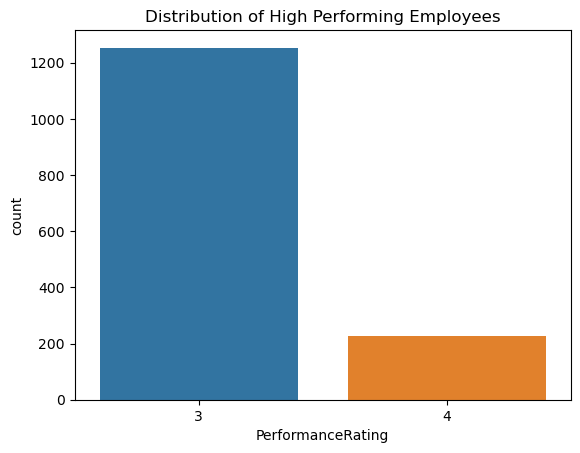

In [7]:
sns.countplot(x = 'PerformanceRating', data = data)
plt.title('Distribution of High Performing Employees')
plt.show()

In [8]:
data['High_performer'] = data['PerformanceRating'].apply(
    lambda x : 1 if x >= 4 else 0
)

In [9]:
data[['High_performer', 'PerformanceRating']].head(11)

,High_performer,PerformanceRating
0,0,3
1,0,3
2,0,3
3,0,3
4,0,3
5,0,3
6,0,3
7,0,3
8,0,3
9,0,3


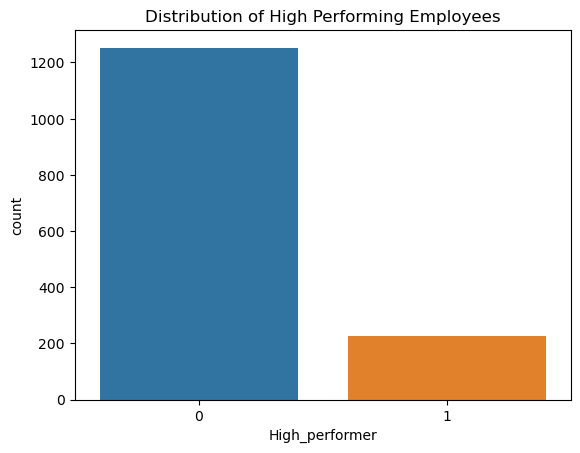

In [10]:
sns.countplot(x = 'High_performer', data = data)
plt.title('Distribution of High Performing Employees')
plt.show() # 0 = Low performer
           # 1 = High performer

In [11]:
numeric_data = data.select_dtypes(include = ['int64', 'float64'])

In [12]:
numeric_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1480 non-null   int64  
 1   DailyRate                 1480 non-null   int64  
 2   DistanceFromHome          1480 non-null   int64  
 3   Education                 1480 non-null   int64  
 4   EmployeeCount             1480 non-null   int64  
 5   EmployeeNumber            1480 non-null   int64  
 6   EnvironmentSatisfaction   1480 non-null   int64  
 7   HourlyRate                1480 non-null   int64  
 8   JobInvolvement            1480 non-null   int64  
 9   JobLevel                  1480 non-null   int64  
 10  JobSatisfaction           1480 non-null   int64  
 11  MonthlyIncome             1480 non-null   int64  
 12  MonthlyRate               1480 non-null   int64  
 13  NumCompaniesWorked        1480 non-null   int64  
 14  PercentS

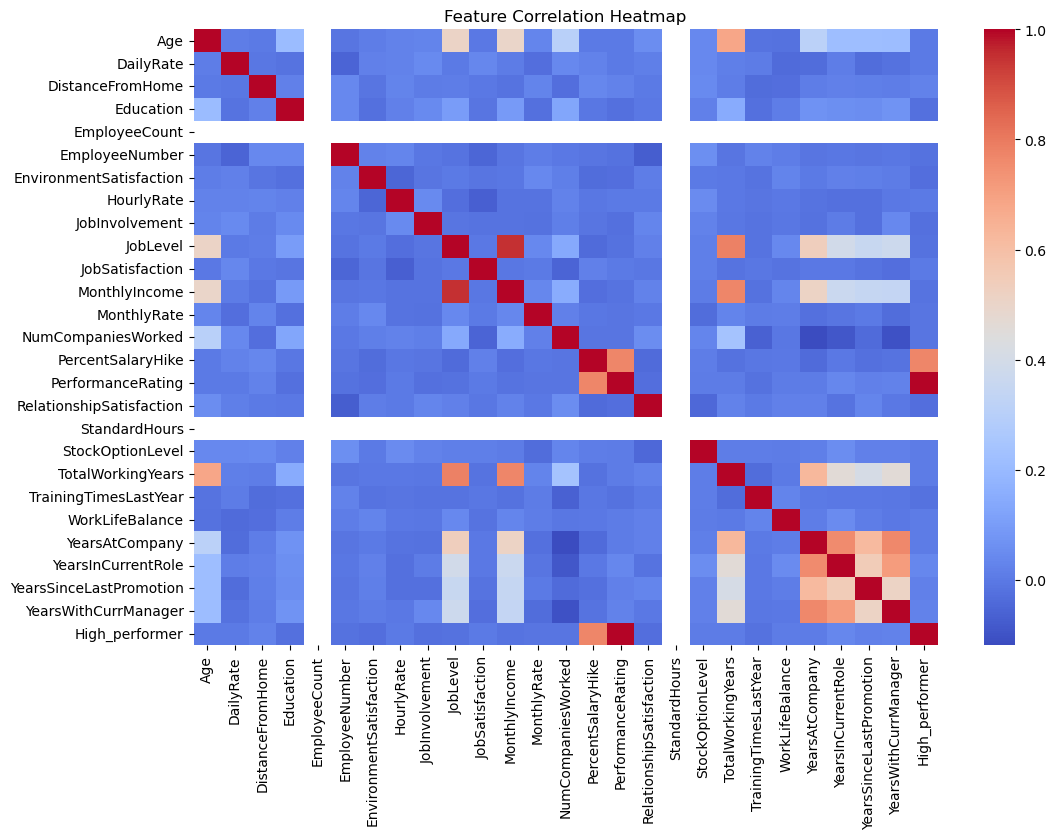

In [13]:
plt.figure(figsize = (12,8))
sns.heatmap(numeric_data.corr(), cmap = 'coolwarm', annot = False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [14]:
data.isnull().sum()

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

In [15]:
le = LabelEncoder()
for col in data.select_dtypes(include = 'object').columns:
    data[col] = le.fit_transform(data[col])

In [16]:
x = data.drop("High_performer", axis = 1)
y = data["High_performer"]

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size = 0.2, random_state = 42
)

In [18]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
corr = pd.Series(data.corr()['High_performer'])
corr.sort_values(ascending = False)

High_performer              1.000000
PerformanceRating           1.000000
PercentSalaryHike           0.772420
YearsInCurrentRole          0.033798
DistanceFromHome            0.024221
YearsWithCurrManager        0.021320
YearsSinceLastPromotion     0.017239
SalarySlab                  0.011343
OverTime                    0.007863
AgeGroup                    0.006057
TotalWorkingYears           0.005320
StockOptionLevel            0.004941
MaritalStatus               0.004526
WorkLifeBalance             0.003438
YearsAtCompany              0.003021
Attrition                   0.002531
JobSatisfaction             0.002421
HourlyRate                  0.000750
Age                         0.000146
DailyRate                  -0.001379
EducationField             -0.008332
MonthlyRate                -0.011296
Gender                     -0.012838
NumCompaniesWorked         -0.014278
MonthlyIncome              -0.017379
BusinessTravel             -0.018610
TrainingTimesLastYear      -0.019123
J

In [20]:
from sklearn.feature_selection import SelectKBest, chi2

In [21]:
x.isnull().sum()

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

In [22]:
x['YearsWithCurrManager'].fillna(
   x['YearsWithCurrManager'].median(),
    inplace = True
)

In [23]:
x.isnull().sum()

EmpID                       0
Age                         0
AgeGroup                    0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
SalarySlab                  0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBa

In [24]:
x = x.drop(columns=['EmpID'])

In [25]:
selector = SelectKBest(score_func = chi2, k = 8)
x_kbest = selector.fit_transform(abs (x), y)
selected_feature = x.columns[selector.get_support()]
selected_feature

Index(['DistanceFromHome', 'EmployeeNumber', 'MonthlyIncome', 'MonthlyRate',
       'PercentSalaryHike', 'PerformanceRating', 'YearsInCurrentRole',
       'YearsSinceLastPromotion'],
      dtype='object')

In [26]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression 

In [27]:
model = LogisticRegression(max_iter = 1000)
rfe = RFE(model, n_features_to_select = 8)
rfe.fit(x,y)

rfe_features = x.columns[rfe.support_]
rfe_features

C:\Users\raiss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\raiss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Index(['AgeGroup', 'Department', 'JobLevel', 'SalarySlab', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours'],
      dtype='object')

In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

In [30]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')
x_train = imputer.fit_transform(x_train)
x_test = imputer.fit_transform(x_test)

In [31]:
np.isnan(x_train).sum()
np.isnan(x_test).sum()

0

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf = RandomForestClassifier(n_estimators = 100 , random_state = 42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

In [35]:
gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)
gb_pred = gb.predict(x_test)

In [36]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

In [3]:
def evaluate_model(y_test, y_pred):
    print('Accuracy', accuracy_score(y_test, y_pred))
    print('Recall', recall_score(y_test, y_pred))
    print('F1_score', precision_score(y_test, y_pred))
    print('Precision', f1_score(y_test, y_pred))

In [4]:
print('LogisticRegression :')
evaluate_model(y_test, lr_pred)

print('\nRandomForestClassifier :')
evaluate_model(y_test, rf_pred)

print('\nGradientBoostClassifier :')
evaluate_model(y_test, gb_pred)

LogisticRegression :


NameError: name 'y_test' is not defined

In [39]:
roc_auc_score(y_test, rf.predict_proba(x_test)[:,1])

1.0

In [1]:
print("Selected by RFE:", len(selected_features))
print("RF importances:", len(rf.feature_importances_))


NameError: name 'selected_features' is not defined

In [41]:
lr = LogisticRegression(max_iter = 1000)
rfe = RFE(lr, n_features_to_select = 8)
rfe.fit(x, y)

selected_features = x.columns[rfe.support_]

x_rfe = x[selected_features]

rf = RandomForestClassifier(random_state = 2)
rf.fit(x_rfe, y)

selected_features = x.columns[rfe.support_]

importance = pd.DataFrame({
    'Feature' : selected_features,
    'Importance' : rf.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

importance.head(10)

C:\Users\raiss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\raiss\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

,Feature,Importance
4,PercentSalaryHike,0.497659
5,PerformanceRating,0.494262
6,RelationshipSatisfaction,0.001892
0,AgeGroup,0.001888
2,JobLevel,0.001711
1,Department,0.001534
3,SalarySlab,0.001054
7,StandardHours,0.000000


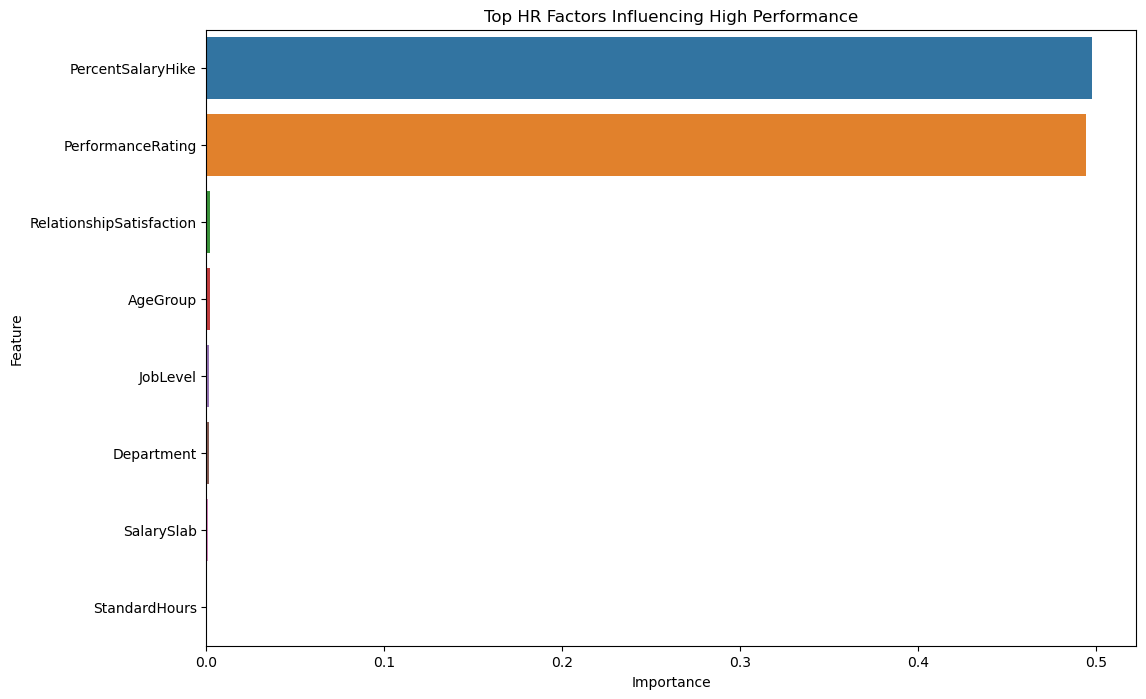

In [42]:
plt.figure(figsize = (12, 8))
sns.barplot(x = 'Importance', y = 'Feature', data = importance.head(8))
plt.title('Top HR Factors Influencing High Performance')
plt.show()